In [1]:
!pip install transformers[torch] datasets evaluate accelerate

import torch
import pandas as pd
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Check if GPU is available (Crucial for BERT!)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.7 MB/s eta 0:00:00
Using device: cpu


In [2]:
# Cell 2: Data Loading and Tokenization
from datasets import load_dataset
from transformers import AutoTokenizer

# 1. Load the IMDB dataset (standard for sentiment analysis)
dataset = load_dataset("imdb")

# 2. Select a subset for faster training during the internship task
# Using 1000 for train and 200 for test gives a good balance of speed and accuracy
train_dataset = dataset["train"].shuffle(seed=42).select(range(1000))
test_dataset = dataset["test"].shuffle(seed=42).select(range(200))

# 3. Load the BERT-base-uncased tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# 4. Define tokenization function
def tokenize_function(examples):
    # padding="max_length" ensures all sequences are 512 tokens
    # truncation=True cuts off reviews longer than 512 tokens
    return tokenizer(examples["text"], padding="max_length", truncation=True)

# 5. Map the function across the datasets
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

# 6. Format for PyTorch (Required for BERT Fine-tuning)
tokenized_train.set_format("torch", columns=["input_ids", "attention_mask", "label"])
tokenized_test.set_format("torch", columns=["input_ids", "attention_mask", "label"])

print("Step 2 Complete: Data is tokenized and ready for BERT!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Step 2 Complete: Data is tokenized and ready for BERT!


In [4]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00


In [6]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
import evaluate

# 1. Load Metric
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

# 2. Load Model
model_frozen = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

# 3. FREEZE all BERT layers
for param in model_frozen.bert.parameters():
    param.requires_grad = False

# 4. Define Training Arguments (Optimized for speed)
training_args_frozen = TrainingArguments(
    output_dir="./results_frozen",
    eval_strategy="epoch",      # Modern naming to avoid warnings
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    report_to="none"            # Prevents unwanted cloud logging
)

# 5. Initialize Trainer
trainer_frozen = Trainer(
    model=model_frozen,
    args=training_args_frozen,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

print("Starting Experiment 1: Frozen BERT...")
trainer_frozen.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting Experiment 1: Frozen BERT...


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.694753,0.510000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=63, training_loss=0.6979410686190166, metrics={'train_runtime': 46.4294, 'train_samples_per_second': 21.538, 'train_steps_per_second': 1.357, 'total_flos': 263111055360000.0, 'train_loss': 0.6979410686190166, 'epoch': 1.0})

In [7]:
# 1. Load a fresh BERT model
model_tuned = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

# 2. Freeze all layers first
for param in model_tuned.bert.parameters():
    param.requires_grad = False

# 3. UNFREEZE the last 2 layers of the BERT encoder
# BERT has 12 layers (indexed 0-11). We unfreeze 10 and 11.
for param in model_tuned.bert.encoder.layer[-2:].parameters():
    param.requires_grad = True

# 4. Define Training Arguments
training_args_tuned = TrainingArguments(
    output_dir="./results_tuned",
    eval_strategy="epoch",
    learning_rate=2e-5,          # Standard BERT learning rate
    per_device_train_batch_size=16,
    num_train_epochs=2,          # 2 epochs gives better fine-tuning results
    weight_decay=0.01,
    report_to="none"
)

# 5. Initialize Trainer
trainer_tuned = Trainer(
    model=model_tuned,
    args=training_args_tuned,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

print("Starting Experiment 2: Fine-tuning Last 2 Layers...")
trainer_tuned.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting Experiment 2: Fine-tuning Last 2 Layers...


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.599873,0.740000
2,No log,0.538705,0.795000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=126, training_loss=0.6068435547843812, metrics={'train_runtime': 104.7024, 'train_samples_per_second': 19.102, 'train_steps_per_second': 1.203, 'total_flos': 526222110720000.0, 'train_loss': 0.6068435547843812, 'epoch': 2.0})

Generating predictions...


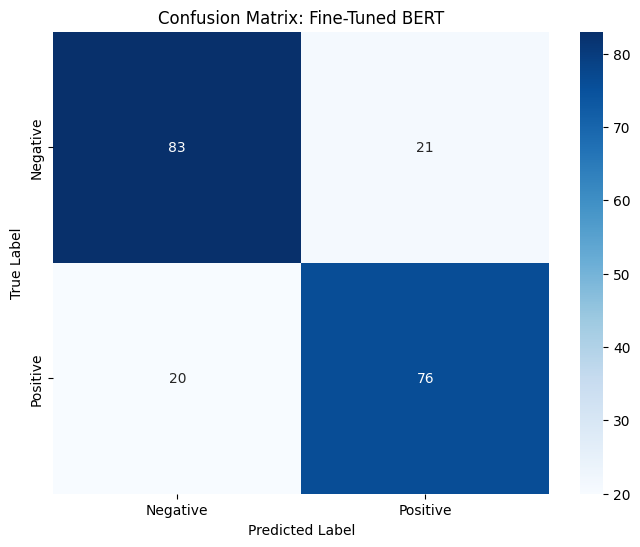


--- Detailed Classification Report ---
              precision    recall  f1-score   support

    Negative       0.81      0.80      0.80       104
    Positive       0.78      0.79      0.79        96

    accuracy                           0.80       200
   macro avg       0.79      0.79      0.79       200
weighted avg       0.80      0.80      0.80       200


--- Final Metrics Summary ---
test_loss: 0.5387
test_accuracy: 0.7950
test_runtime: 6.2902
test_samples_per_second: 31.7960
test_steps_per_second: 3.9740


In [10]:
import torch # This was missing!
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. Get predictions (using the fine-tuned model from Cell 4)
print("Generating predictions...")
preds_output = trainer_tuned.predict(tokenized_test)

# 2. Convert logits to class labels (0 or 1)
y_preds = np.argmax(preds_output.predictions, axis=-1)

# 3. Extract true labels safely
# We use .numpy() to ensure it's in a format sklearn understands
y_true = np.array(tokenized_test["label"])

# 4. Generate Confusion Matrix
cm = confusion_matrix(y_true, y_preds)

# 5. Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Fine-Tuned BERT')
plt.show()

# 6. Print Detailed Report (Required for Evaluation Criteria)
print("\n--- Detailed Classification Report ---")
print(classification_report(y_true, y_preds, target_names=['Negative', 'Positive']))

print("\n--- Final Metrics Summary ---")
for key, value in preds_output.metrics.items():
    if "test_" in key: # Only show the relevant test metrics
        print(f"{key}: {value:.4f}")